In [1]:
# Install Ultralytics for YOLO models
# Install pycocotools for reading the COCO annotation file
!pip install -q ultralytics pycocotools

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 6.6 MB/s eta 0:00:00


In [2]:
# Create a folder where the Kaggle ZIP file will be downloaded
!mkdir -p /content/kaggle_data

In [3]:
# Import Colab's file upload tool
from google.colab import files

# Open a file picker and upload your kaggle.json file
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [4]:
# Create the Kaggle configuration folder
!mkdir -p /root/.kaggle

# Copy the uploaded Kaggle API key to the required location
!cp kaggle.json /root/.kaggle/kaggle.json

# Protect the API key so only the current user can access it
!chmod 600 /root/.kaggle/kaggle.json

# Test that Kaggle authentication is working
!kaggle competitions list | head

ref                                                                           deadline             category         reward  teamCount  userHasEntered  
----------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge   2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                            2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                    2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection          2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3                  2026-11-02

In [5]:
# Download the Garbage Segmentation competition dataset from Kaggle
# The -p option tells Kaggle where to save the ZIP file
!kaggle competitions download -c garbage-segmentation -p /content/kaggle_data

100% 1.87G/1.87G [00:21<00:00, 94.1MB/s]



In [6]:
# Create a folder where we will extract the dataset
!mkdir -p /content/garbage_segmentation

# Extract the downloaded ZIP file
!unzip -q /content/kaggle_data/*.zip -d /content/garbage_segmentation

In [7]:
# Import os so we can inspect folders and files
import os

# Define the location of the extracted dataset
dataset_path = "/content/garbage_segmentation/garbage_segmentation_dataset"

# Check whether the dataset folder exists
print("Dataset exists:", os.path.exists(dataset_path))

# Show the files and folders inside the dataset
print("\nDataset contents:")
for item in os.listdir(dataset_path):
    print("-", item)

Dataset exists: True

Dataset contents:
- sample_submission.csv
- test
- train_json.json
- train
- test-without_segmentation.json


In [8]:
# Import the libraries needed to read the annotation file
import json
import os

# Define the path to the COCO annotation file
annotation_file = "/content/garbage_segmentation/garbage_segmentation_dataset/train_json.json"

# Open and read the JSON annotation file
with open(annotation_file, "r") as f:
    coco_data = json.load(f)

# Display the main sections in the annotation file
print("Annotation sections:")
print(coco_data.keys())

# Count the images, annotations, and categories
print("\nNumber of images:", len(coco_data["images"]))
print("Number of annotations:", len(coco_data["annotations"]))
print("Number of categories:", len(coco_data["categories"]))

Annotation sections:
dict_keys(['images', 'annotations', 'categories'])

Number of images: 941
Number of annotations: 2461
Number of categories: 6


In [9]:
# Print all categories contained in the dataset
print("Categories in the dataset:\n")

for category in coco_data["categories"]:

    # Get the category ID
    category_id = category["id"]

    # Get the category name
    category_name = category["name"]

    # Display the category information
    print(category_id, "->", category_name)

Categories in the dataset:

0 -> biowaste
1 -> glass
2 -> household waste
3 -> metal
4 -> paper/cardboard
5 -> plastic


In [10]:
# Define where the new single-item classification dataset will be stored
classification_path = "/content/waste_classification"

# Define the five usable waste categories
classification_classes = [
    "glass",
    "household_waste",
    "metal",
    "paper_cardboard",
    "plastic"
]

# Create train and validation folders
os.makedirs(
    os.path.join(classification_path, "train"),
    exist_ok=True
)

os.makedirs(
    os.path.join(classification_path, "val"),
    exist_ok=True
)

# Create a folder for every waste category inside train and val
for class_name in classification_classes:

    # Create the training class folder
    os.makedirs(
        os.path.join(classification_path, "train", class_name),
        exist_ok=True
    )

    # Create the validation class folder
    os.makedirs(
        os.path.join(classification_path, "val", class_name),
        exist_ok=True
    )

# Display the created folder structure
print("Classification dataset folders created successfully!")

for split in ["train", "val"]:

    print(f"\n{split} folders:")

    for class_name in classification_classes:
        print(
            "-",
            os.path.join(
                classification_path,
                split,
                class_name
            )
        )

Classification dataset folders created successfully!

train folders:
- /content/waste_classification/train/glass
- /content/waste_classification/train/household_waste
- /content/waste_classification/train/metal
- /content/waste_classification/train/paper_cardboard
- /content/waste_classification/train/plastic

val folders:
- /content/waste_classification/val/glass
- /content/waste_classification/val/household_waste
- /content/waste_classification/val/metal
- /content/waste_classification/val/paper_cardboard
- /content/waste_classification/val/plastic


In [11]:
# Import the libraries needed for image processing
import os
import cv2
import numpy as np
from PIL import Image
from collections import defaultdict


# ---------------------------------------------------------
# DEFINE PATHS
# ---------------------------------------------------------

# Path to the original training images
train_images_path = "/content/garbage_segmentation/garbage_segmentation_dataset/train"

# Path to our new classification dataset
classification_path = "/content/waste_classification"


# ---------------------------------------------------------
# MAP COCO CATEGORY NAMES TO OUR FOLDER NAMES
# ---------------------------------------------------------

# COCO category names in the original dataset
# are slightly different from our folder names
category_name_mapping = {
    "glass": "glass",
    "household waste": "household_waste",
    "metal": "metal",
    "paper/cardboard": "paper_cardboard",
    "plastic": "plastic"
}


# ---------------------------------------------------------
# CREATE IMAGE LOOKUP
# ---------------------------------------------------------

# Create a dictionary that lets us quickly find an image
# using its COCO image ID
image_info = {}

for image in coco_data["images"]:

    # Store the complete image information using its ID
    image_info[image["id"]] = image


# ---------------------------------------------------------
# CREATE CATEGORY LOOKUP
# ---------------------------------------------------------

# Create a dictionary that converts category ID → category name
category_info = {}

for category in coco_data["categories"]:

    category_info[category["id"]] = category["name"]


# ---------------------------------------------------------
# GROUP ANNOTATIONS BY IMAGE
# ---------------------------------------------------------

# Create a dictionary where:
# image ID → all annotations belonging to that image
annotations_by_image = defaultdict(list)

for annotation in coco_data["annotations"]:

    annotations_by_image[annotation["image_id"]].append(annotation)


# ---------------------------------------------------------
# GET ALL IMAGE IDs
# ---------------------------------------------------------

# Get all image IDs from the annotation file
all_image_ids = list(image_info.keys())

# Sort them so the split is reproducible
all_image_ids.sort()


# ---------------------------------------------------------
# CREATE TRAIN / VALIDATION IMAGE SPLIT
# ---------------------------------------------------------

# Use approximately 80% of the original images for training
split_index = int(len(all_image_ids) * 0.80)

# First 80% of images
train_image_ids = set(all_image_ids[:split_index])

# Remaining 20% of images
val_image_ids = set(all_image_ids[split_index:])


# ---------------------------------------------------------
# COUNTERS
# ---------------------------------------------------------

# Keep track of how many objects we successfully extract
train_counts = defaultdict(int)
val_counts = defaultdict(int)

total_objects = 0
skipped_objects = 0


# ---------------------------------------------------------
# PROCESS EVERY ANNOTATED IMAGE
# ---------------------------------------------------------

for image_id, annotations in annotations_by_image.items():

    # Get information about this image
    image_data = image_info[image_id]

    # Get the filename of the original image
    image_filename = image_data["file_name"]

    # Build the full image path
    image_path = os.path.join(
        train_images_path,
        image_filename
    )

    # Skip the image if it cannot be found
    if not os.path.exists(image_path):

        print("Image not found:", image_path)

        continue


    # -----------------------------------------------------
    # DETERMINE TRAIN OR VALIDATION
    # -----------------------------------------------------

    if image_id in train_image_ids:

        # Save objects from this image in train
        split = "train"

    else:

        # Save objects from this image in validation
        split = "val"


    # -----------------------------------------------------
    # LOAD ORIGINAL IMAGE
    # -----------------------------------------------------

    # Open the image using OpenCV
    image = cv2.imread(image_path)

    # Skip if OpenCV could not read the image
    if image is None:

        print("Could not read:", image_path)

        continue


    # Get image dimensions
    image_height, image_width = image.shape[:2]


    # -----------------------------------------------------
    # PROCESS EACH WASTE OBJECT
    # -----------------------------------------------------

    for object_number, annotation in enumerate(annotations):

        # Get the original category ID
        category_id = annotation["category_id"]

        # Convert category ID to category name
        original_category = category_info.get(category_id)


        # Skip categories we are not using
        if original_category not in category_name_mapping:

            skipped_objects += 1

            continue


        # Convert the original category name
        # into our folder name
        class_name = category_name_mapping[original_category]


        # -------------------------------------------------
        # GET SEGMENTATION POLYGON
        # -------------------------------------------------

        segmentation = annotation.get("segmentation", [])


        # Skip annotations without segmentation data
        if not segmentation:

            skipped_objects += 1

            continue


        # Some COCO annotations can contain multiple polygons.
        # We combine them into one mask.
        mask = np.zeros(
            (image_height, image_width),
            dtype=np.uint8
        )


        # -------------------------------------------------
        # DRAW THE OBJECT MASK
        # -------------------------------------------------

        for polygon in segmentation:

            # Convert polygon coordinates into NumPy array
            polygon_array = np.array(
                polygon,
                dtype=np.float32
            ).reshape(-1, 2)

            # Convert coordinates to integer pixels
            polygon_array = np.round(
                polygon_array
            ).astype(np.int32)

            # Draw the polygon on the mask
            cv2.fillPoly(
                mask,
                [polygon_array],
                255
            )


        # -------------------------------------------------
        # GET OBJECT BOUNDING BOX
        # -------------------------------------------------

        # Find the coordinates of all pixels belonging
        # to the object
        ys, xs = np.where(mask > 0)


        # Skip invalid masks
        if len(xs) == 0 or len(ys) == 0:

            skipped_objects += 1

            continue


        # Get bounding box coordinates
        x_min = max(0, xs.min())
        x_max = min(image_width, xs.max() + 1)

        y_min = max(0, ys.min())
        y_max = min(image_height, ys.max() + 1)


        # -------------------------------------------------
        # CROP IMAGE AND MASK
        # -------------------------------------------------

        # Crop the original image
        cropped_image = image[
            y_min:y_max,
            x_min:x_max
        ]

        # Crop the corresponding mask
        cropped_mask = mask[
            y_min:y_max,
            x_min:x_max
        ]


        # -------------------------------------------------
        # APPLY THE MASK
        # -------------------------------------------------

        # Create a white background
        background = np.ones_like(
            cropped_image
        ) * 255

        # Keep the waste object pixels
        # and replace everything outside the object
        # with white
        masked_object = np.where(
            cropped_mask[:, :, None] > 0,
            cropped_image,
            background
        )


        # -------------------------------------------------
        # ADD A SMALL BORDER
        # -------------------------------------------------

        # Add some surrounding context around the object.
        # This helps the classifier see the complete item
        # without making the crop excessively large.
        padding = 10

        # Add white padding around the object
        masked_object = cv2.copyMakeBorder(
            masked_object,
            padding,
            padding,
            padding,
            padding,
            cv2.BORDER_CONSTANT,
            value=(255, 255, 255)
        )


        # -------------------------------------------------
        # CREATE OUTPUT FILENAME
        # -------------------------------------------------

        # Remove the extension from the original filename
        original_name = os.path.splitext(
            image_filename
        )[0]

        # Create a unique filename for this object
        output_filename = (
            f"{original_name}_object_{object_number}.jpg"
        )


        # -------------------------------------------------
        # SAVE OBJECT IMAGE
        # -------------------------------------------------

        # Create the destination folder
        output_folder = os.path.join(
            classification_path,
            split,
            class_name
        )

        # Make sure the folder exists
        os.makedirs(
            output_folder,
            exist_ok=True
        )

        # Create the complete output path
        output_path = os.path.join(
            output_folder,
            output_filename
        )

        # Save the cropped object
        cv2.imwrite(
            output_path,
            masked_object
        )


        # Update counters
        if split == "train":

            train_counts[class_name] += 1

        else:

            val_counts[class_name] += 1

        total_objects += 1


# ---------------------------------------------------------
# DISPLAY RESULTS
# ---------------------------------------------------------

print("\n========================================")
print("OBJECT EXTRACTION COMPLETE")
print("========================================")

print("\nTraining objects:")

for class_name in classification_classes:

    print(
        f"{class_name}:",
        train_counts[class_name]
    )


print("\nValidation objects:")

for class_name in classification_classes:

    print(
        f"{class_name}:",
        val_counts[class_name]
    )


print("\nTotal extracted objects:", total_objects)

print("Skipped objects:", skipped_objects)


OBJECT EXTRACTION COMPLETE

Training objects:
glass: 154
household_waste: 541
metal: 362
paper_cardboard: 300
plastic: 609

Validation objects:
glass: 137
household_waste: 127
metal: 55
paper_cardboard: 61
plastic: 115

Total extracted objects: 2461
Skipped objects: 0


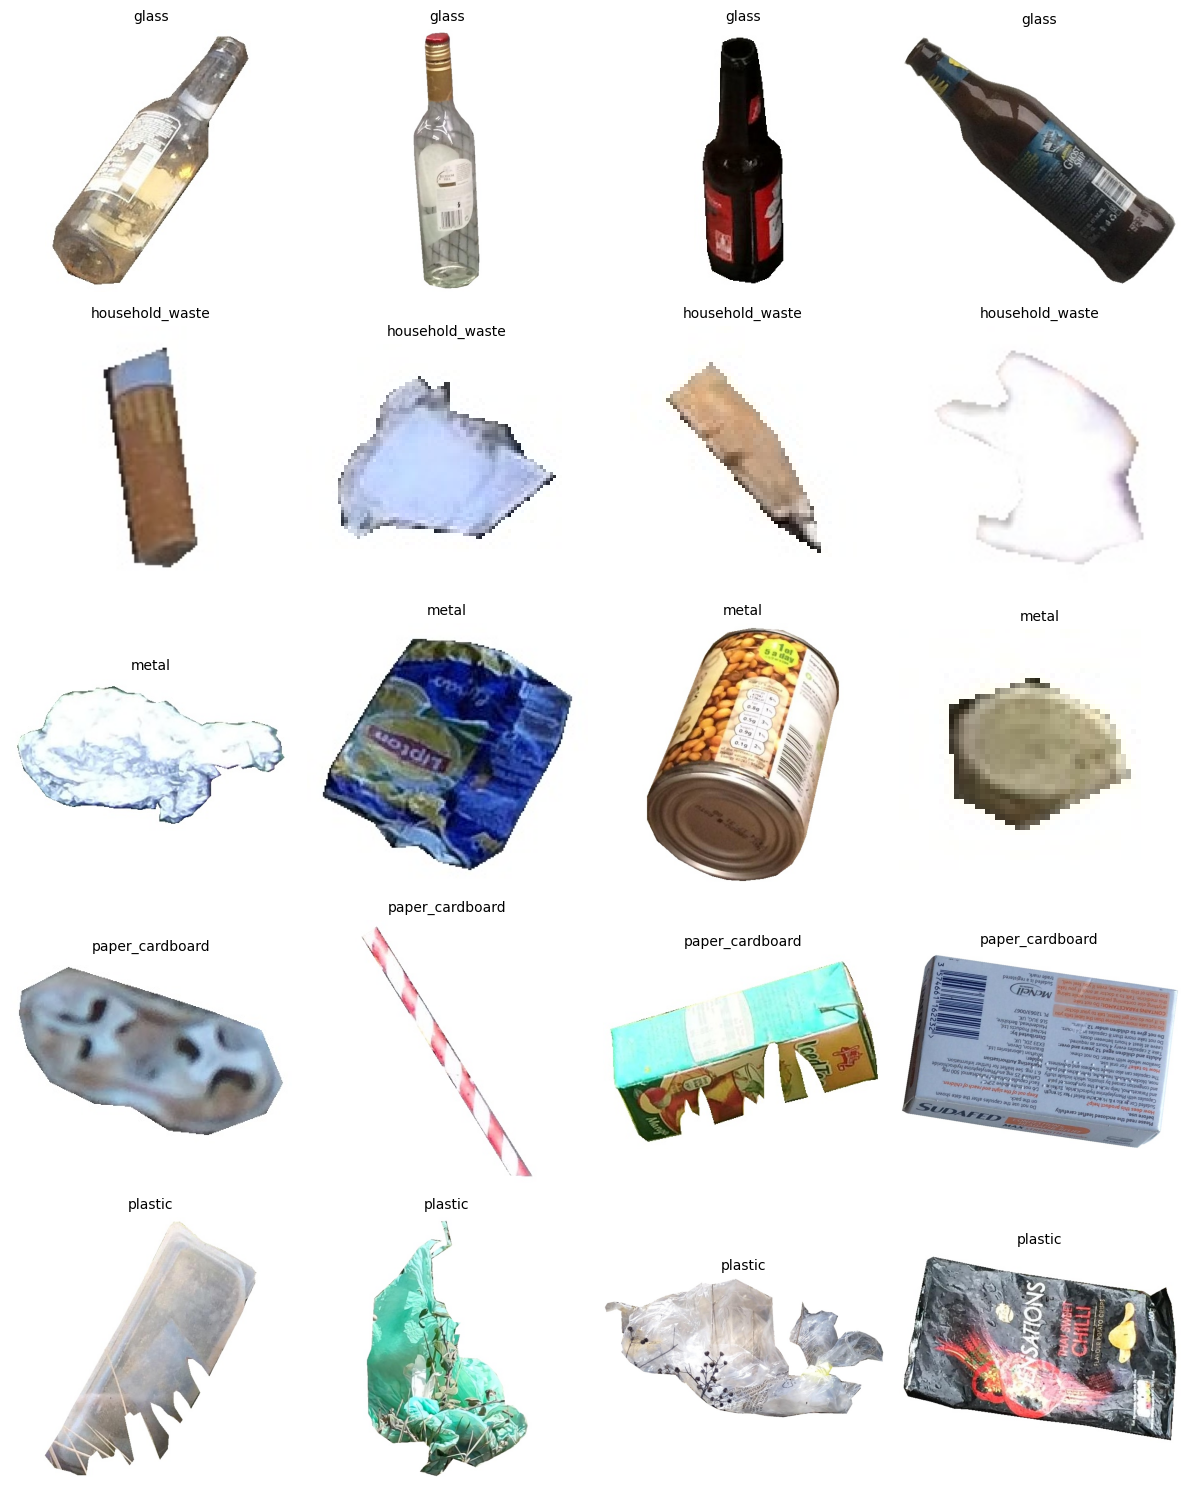

In [12]:
# Import libraries for displaying images
import os
import random
import matplotlib.pyplot as plt
from PIL import Image


# ---------------------------------------------------------
# SELECT CLASSES TO INSPECT
# ---------------------------------------------------------

# These are the five classes in our classification dataset
classes_to_check = [
    "glass",
    "household_waste",
    "metal",
    "paper_cardboard",
    "plastic"
]


# ---------------------------------------------------------
# CREATE A FIGURE
# ---------------------------------------------------------

# Create a figure with 5 rows and 4 columns
# Each row represents one waste category
fig, axes = plt.subplots(
    5,
    4,
    figsize=(12, 15)
)


# ---------------------------------------------------------
# DISPLAY RANDOM OBJECTS
# ---------------------------------------------------------

# Process each waste category
for row, class_name in enumerate(classes_to_check):

    # Path to the training images for this class
    class_folder = os.path.join(
        classification_path,
        "train",
        class_name
    )

    # Get all image files
    image_files = [
        filename
        for filename in os.listdir(class_folder)
        if filename.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ]

    # Randomly select up to 4 images
    selected_images = random.sample(
        image_files,
        min(4, len(image_files))
    )

    # Display each selected image
    for column, filename in enumerate(selected_images):

        # Build the image path
        image_path = os.path.join(
            class_folder,
            filename
        )

        # Open the image
        image = Image.open(image_path)

        # Display the image
        axes[row, column].imshow(image)

        # Remove axis numbers
        axes[row, column].axis("off")

        # Add the filename as a small title
        axes[row, column].set_title(
            class_name,
            fontsize=10
        )


# ---------------------------------------------------------
# DISPLAY THE COMPLETE FIGURE
# ---------------------------------------------------------

# Add spacing between images
plt.tight_layout()

# Show the figure
plt.show()

In [13]:
# Import YOLO from Ultralytics
from ultralytics import YOLO

# Load a pretrained YOLO11 small classification model
# The pretrained model gives us a strong starting point
# instead of training completely from zero
classifier = YOLO("yolo11s-cls.pt")

# Confirm that the model has loaded
print("Classification model loaded successfully!")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Classification model loaded successfully!


In [16]:
# Train the classification model using the CPU
classifier.train(

    # Path to our classification dataset
    data="/content/waste_classification",

    # Number of training epochs
    epochs=25,

    # Image size used by the classifier
    imgsz=224,

    # Smaller batch size to reduce CPU memory usage
    batch=16,

    # Use CPU instead of GPU
    device="cpu",

    # Use two workers to load images
    workers=2,

    # Stop early if validation performance stops improving
    patience=8,

    # Give this training run a clear name
    name="waste_single_item_classifier_cpu"
)

Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/waste_classification, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=waste_single_item_classifier_cpu-2, nbs

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78ca1bd217f0>
curves: []
curves_results: []
fitness: 0.7828282713890076
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.5656565427780151, 'metrics/accuracy_top5': 1.0, 'fitness': 0.7828282713890076}
save_dir: PosixPath('/content/runs/classify/waste_single_item_classifier_cpu-2')
speed: {'preprocess': 0.0011004020199485388, 'inference': 34.69503368283363, 'loss': 5.3933333467946134e-05, 'postprocess': 0.00013446666766546027}
top1: 0.5656565427780151
top5: 1.0

In [17]:
# Import YOLO
from ultralytics import YOLO

# Load the best single-item classification model
classifier_best = YOLO(
    "/content/runs/classify/waste_single_item_classifier_cpu-2/weights/best.pt"
)

# Validate the trained classifier on our validation dataset
validation_results = classifier_best.val(
    data="/content/waste_classification",
    imgsz=224,
    batch=16,
    device="cpu"
)

# Print the validation accuracy
print("\nTop-1 accuracy:",
      validation_results.top1)

print("Top-5 accuracy:",
      validation_results.top5)

Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO11s-cls summary (fused): 47 layers, 5,440,533 parameters, 0 gradients, 12.1 GFLOPs
train: /content/waste_classification/train... found 1966 images in 5 classes ✅ 
val: /content/waste_classification/val... found 495 images in 5 classes ✅ 
test: None...
WARNING ⚠️ val: Slow image access detected (ping: 0.8±1.8 ms, read: 37.9±21.2 MB/s, size: 3.2 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/waste_classification/val... 495 images, 0 corrupt: 100% ━━━━━━━━━━━━ 495/495 71.6Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 31/31 1.1it/s 27.8s
                   all      0.566          1
Speed: 0.0ms preprocess, 38.5ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val

Top-1 accuracy: 0.5656565427780151
Top-5 accuracy: 1

In [19]:
# Import matplotlib for displaying the confusion matrix
import matplotlib.pyplot as plt

# Get the confusion matrix object from the validation results
confusion_matrix = validation_results.confusion_matrix

# Create the confusion matrix plot
confusion_matrix.plot()

# Display the plot
plt.show()

In [20]:
# Import Colab's file download tool
from google.colab import files

# Define the path to the best trained classification model
classifier_path = "/content/runs/classify/waste_single_item_classifier_cpu-2/weights/best.pt"

# Download the trained model to your computer
files.download(classifier_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
# Import Colab's file upload tool
from google.colab import files

# Open the file picker
# Select multiple single-item images from your computer
uploaded_test_images = files.upload()

# Display the uploaded filenames
print("\nUploaded test images:")

for filename in uploaded_test_images.keys():
    print("-", filename)

# Display the total number of images
print("\nTotal images:", len(uploaded_test_images))

Saving images (3).jpeg to images (3) (1).jpeg

Uploaded test images:
- images (3) (1).jpeg

Total images: 1


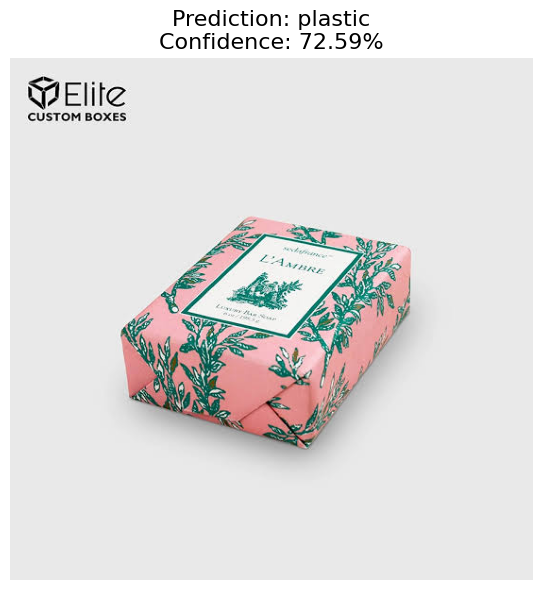


Image: images (3) (1).jpeg
Top predictions:
1. plastic -> 72.59%
2. glass -> 25.96%
3. paper_cardboard -> 0.87%
4. household_waste -> 0.33%
5. metal -> 0.25%


In [29]:
# Import the required libraries
from ultralytics import YOLO
from PIL import Image
import numpy as np
import os
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# LOAD THE TRAINED CLASSIFICATION MODEL
# ---------------------------------------------------------

# Load the best classifier we trained
classifier = YOLO(
    "/content/runs/classify/waste_single_item_classifier_cpu-2/weights/best.pt"
)


# ---------------------------------------------------------
# CLASS NAMES
# ---------------------------------------------------------

# These are the five classes used during training
class_names = [
    "glass",
    "household_waste",
    "metal",
    "paper_cardboard",
    "plastic"
]


# ---------------------------------------------------------
# TEST EVERY UPLOADED IMAGE
# ---------------------------------------------------------

for filename in uploaded_test_images.keys():

    # Create the complete path to the uploaded image
    image_path = os.path.join(
        "/content",
        filename
    )

    # Open the image
    image = Image.open(image_path).convert("RGB")

    # Run the classification model
    results = classifier.predict(
        source=np.array(image),
        imgsz=224,
        device="cpu",
        verbose=False
    )

    # Get the first prediction result
    result = results[0]

    # Get the predicted class ID
    predicted_class_id = result.probs.top1

    # Get the confidence of the prediction
    predicted_confidence = result.probs.top1conf.item()

    # Convert class ID to class name
    predicted_class = class_names[predicted_class_id]


    # -----------------------------------------------------
    # DISPLAY RESULT
    # -----------------------------------------------------

    # Create a figure
    plt.figure(figsize=(8, 6))

    # Display the original image
    plt.imshow(image)

    # Add prediction and confidence as the title
    plt.title(
        f"Prediction: {predicted_class}\n"
        f"Confidence: {predicted_confidence * 100:.2f}%",
        fontsize=16
    )

    # Remove axis numbers
    plt.axis("off")

    # Adjust the layout
    plt.tight_layout()

    # Show the result
    plt.show()


    # -----------------------------------------------------
    # DISPLAY TOP 5 PREDICTIONS
    # -----------------------------------------------------

    print(f"\nImage: {filename}")
    print("Top predictions:")

    # Get the top 5 predicted class IDs
    top5_class_ids = result.probs.top5

    # Get the corresponding confidence values
    top5_confidences = result.probs.top5conf.cpu().numpy()

    # Display each prediction
    for rank, (class_id, confidence_value) in enumerate(
        zip(top5_class_ids, top5_confidences),
        start=1
    ):

        print(
            f"{rank}. "
            f"{class_names[class_id]} "
            f"-> {confidence_value * 100:.2f}%"
        )